In [ ]:
import pandas as pd #biblioteca que permite generar dataset o dataframe
import numpy as np #biblioteca para calculo, arreglos, matrices, elabora datasets a traves de listas
import matplotlib.pyplot as plt #herramientas graficas
import seaborn as sns
entrenamiento = pd.read_csv('/content/Datos_abiertos_admision_2021_1_2024_1.csv')

In [ ]:
#sacamos las 5 primeras filas
entrenamiento.head(5)

,IDHASH,COLEGIO,COLEGIO_DEPA,COLEGIO_PROV,COLEGIO_DIST,COLEGIO_PAIS,COLEGIO_ANIO_EGRESO,ESPECIALIDAD,ANIO_POSTULA,CICLO_POSTULA,...,DOMICILIO_DIST,ANIO_NACIMIENTO,NACIMIENTO_PAIS,NACIMIENTO_DEPA,NACIMIENTO_PROV,NACIMIENTO_DIST,SEXO,CALIF_FINAL,INGRESO,MODALIDAD
0,E4287C2FE19F63C5E6641955147E36684A5A2FF8064676...,LA DIVINA PROVIDENCIA,LIMA,LIMA,SURQUILLO,PERÚ,2020,INGENIERÍA DE SISTEMAS,2021,1,...,SAN JUAN DE MIRAFLORES,2004,PERÚ,LIMA,LIMA,VILLA EL SALVADOR,MASCULINO,3.11,NO,EXTRAORDINARIO1 - DEPORTISTAS CALIFICADOS DE A...
1,2DC37F0B9727B6591EC72D7A942647797A200F45D47C9E...,86019 LA LIBERTAD,ÁNCASH,HUARAZ,HUARAZ,PERÚ,2017,INGENIERÍA DE TELECOMUNICACIONES,2021,1,...,HUARAZ,2001,PERÚ,ÁNCASH,HUARAZ,HUARAZ,FEMENINO,3.58,NO,ORDINARIO
2,3B8677B90781D7BB8F2F967C05FA2DBBE153BBB682DF05...,0113 DANIEL ALOMIAS ROBLES,LIMA,LIMA,SAN JUAN DE LURIGANCHO,PERÚ,2016,INGENIERÍA MECÁNICA,2021,1,...,SAN JUAN DE LURIGANCHO,2000,PERÚ,LIMA,LIMA,JESÚS MARÍA,MASCULINO,8.04,NO,ORDINARIO
3,FA366704D9E9F6FB5E5F55C1FB0CEEE973C626A5616F55...,SEBASTIAN SALAZAR BONDY,LIMA,LIMA,SANTA ANITA,PERÚ,2018,INGENIERÍA ELECTRÓNICA,2021,1,...,SANTA ANITA,2002,PERÚ,LIMA,LIMA,LIMA,MASCULINO,10.82,NO,EXTRAORDINARIO2 – INGRESO DIRECTO CEPRE
4,E31CF8F30F3AE60B3D8A14F6E1020E9AD26EE975F0823B...,TRILCE LOS OLIVOS,LIMA,LIMA,SAN MARTÍN DE PORRES,PERÚ,2020,ARQUITECTURA,2021,1,...,INDEPENDENCIA,2004,PERÚ,LIMA,LIMA,COMAS,FEMENINO,6.21,NO,ORDINARIO


In [ ]:
#verificamos los campos que hacen ruido(son nulos)
entrenamiento.isnull()

,IDHASH,COLEGIO,COLEGIO_DEPA,COLEGIO_PROV,COLEGIO_DIST,COLEGIO_PAIS,COLEGIO_ANIO_EGRESO,ESPECIALIDAD,ANIO_POSTULA,CICLO_POSTULA,...,DOMICILIO_DIST,ANIO_NACIMIENTO,NACIMIENTO_PAIS,NACIMIENTO_DEPA,NACIMIENTO_PROV,NACIMIENTO_DIST,SEXO,CALIF_FINAL,INGRESO,MODALIDAD
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42511,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
42512,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
42513,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
42514,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


<Axes: >

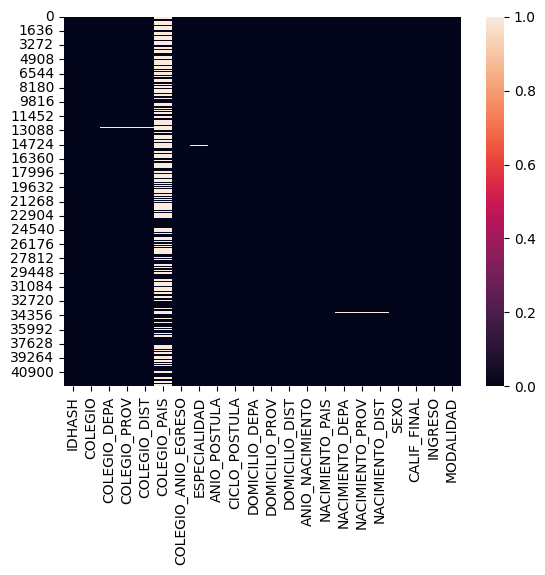

In [ ]:
#usando la libreria seaborn comprobamos los campos nulos del dataset de manera grafica
sns.heatmap(entrenamiento.isnull())

In [ ]:
pais_counts = entrenamiento['COLEGIO_PAIS'].value_counts().reset_index()
pais_counts.columns = ['PAIS', 'CANTIDAD']
print(pais_counts)

        PAIS  CANTIDAD
0       PERÚ     18926
1  VENEZUELA         6
2    ECUADOR         3
3     ESPAÑA         2
4      CHILE         2
5  ARGENTINA         1
6     ITALIA         1
7   COLOMBIA         1


In [ ]:
#vemos claramente una diferencia significativa con respecto al pais del colegio de los postulantes

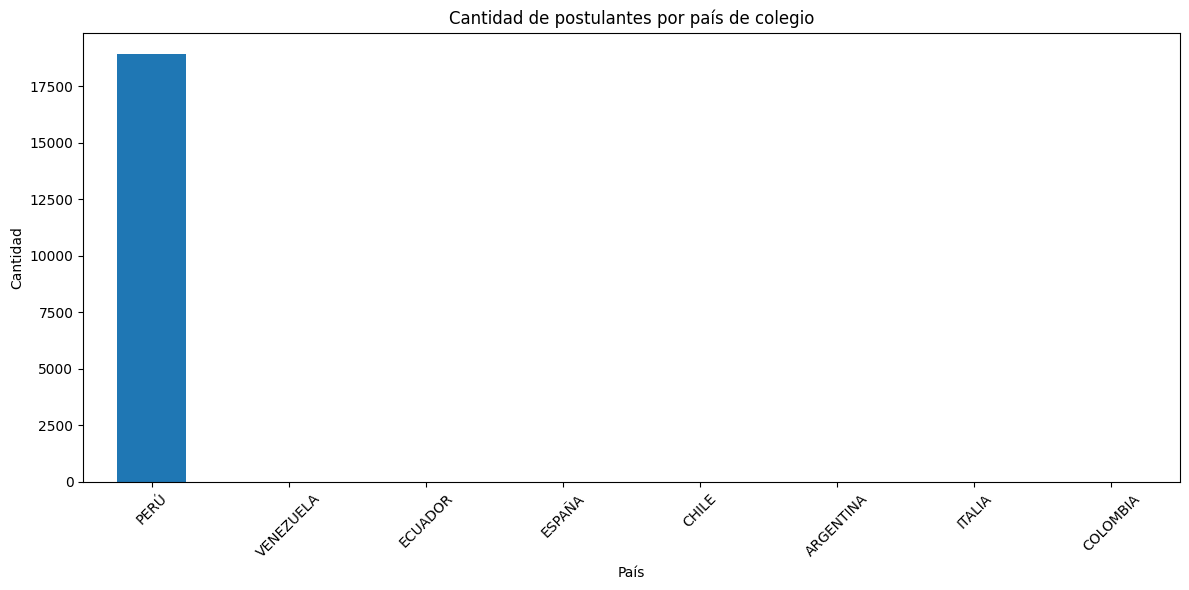

In [ ]:

#usamos la libreria matplotlib para verlo de manera grafica
pais_counts = entrenamiento['COLEGIO_PAIS'].value_counts()


plt.figure(figsize=(12, 6))
pais_counts.plot(kind='bar')
plt.title('Cantidad de postulantes por país de colegio')
plt.xlabel('País')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#entonces debemos llenar los campos nulos en ["COLEGIO_PAIS"]

In [ ]:
#SE RELLENA LOS CAMPOS FALTANTES
def rellenar_colegio_pais(fila):
    if pd.isna(fila['COLEGIO_PAIS']):
        return 'PERÚ'
    return fila['COLEGIO_PAIS']

entrenamiento['COLEGIO_PAIS'] = entrenamiento.apply(rellenar_colegio_pais, axis=1)

<Axes: >

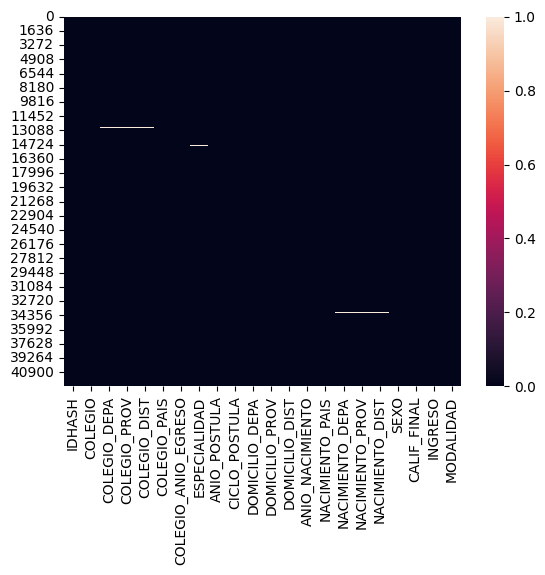

In [ ]:
#debemos comprobar que se hizo correctamente con el mapa de calor
sns.heatmap(entrenamiento.isnull())

In [ ]:
#volvemos a hacer el conteo
pais_counts = entrenamiento['COLEGIO_PAIS'].value_counts().reset_index()
pais_counts.columns = ['PAIS', 'CANTIDAD']
print(pais_counts)

        PAIS  CANTIDAD
0       PERÚ     42500
1  VENEZUELA         6
2    ECUADOR         3
3     ESPAÑA         2
4      CHILE         2
5  ARGENTINA         1
6     ITALIA         1
7   COLOMBIA         1


    ANIO_NACIMIENTO  ANIO_POSTULA  EDAD
0              2004          2021    17
1              2001          2021    20
2              2000          2021    21
3              2002          2021    19
4              2004          2021    17
5              2000          2021    21
6              2002          2021    19
7              1999          2021    22
8              2004          2021    17
9              2003          2021    18
10             2002          2021    19
11             2004          2021    17
12             2000          2021    21
13             2002          2021    19
14             2004          2021    17
15             1997          2024    27
16             2006          2024    18
17             2005          2024    19
18             2005          2024    19
19             2005          2024    19


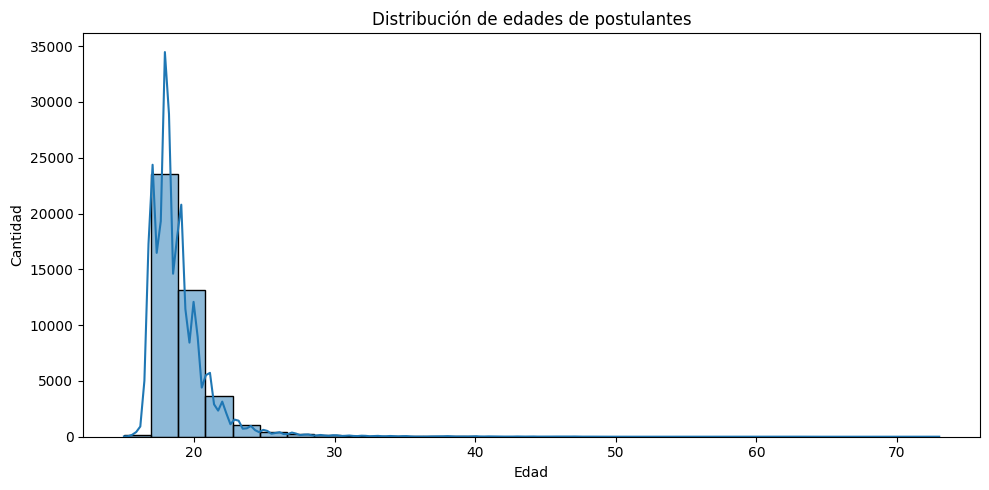

In [ ]:
#podemos inferir datos de la edad de los postulantes en base al año de nacimiento y el año de postulacion
# Inferimos la edad de los postulantes
entrenamiento['EDAD'] = entrenamiento['ANIO_POSTULA'] - entrenamiento['ANIO_NACIMIENTO']

# Mostramos las primeras filas para verificar
print(entrenamiento[['ANIO_NACIMIENTO', 'ANIO_POSTULA', 'EDAD']].head(20))

# Opcional: visualizamos la distribución de edades
plt.figure(figsize=(10, 5))
sns.histplot(entrenamiento['EDAD'], bins=30, kde=True)
plt.title('Distribución de edades de postulantes')
plt.xlabel('Edad')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()


<Axes: >

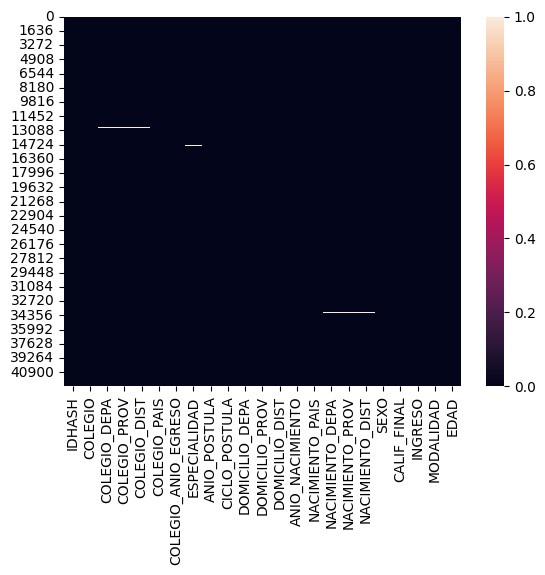

In [ ]:
#comprobamos que la nueva columna ["EDAD"] se haya añadido al dataset
sns.heatmap(entrenamiento.isnull())

In [ ]:

def columnas_con_nulos(entrenamiento):
    # Filtramos las columnas con valores nulos
    columnas_nulas = entrenamiento.isnull().sum()

    # Filtramos solo aquellas columnas que tienen al menos un valor nulo
    columnas_nulas = columnas_nulas[columnas_nulas > 0]

    # Retorna las columnas con nulos y la cantidad de nulos por columna
    return columnas_nulas

# Usamos la función con el DataFrame
columnas_nulas = columnas_con_nulos(entrenamiento)

# Mostrar las columnas con valores nulos
print(columnas_nulas)





COLEGIO_DEPA       226
COLEGIO_PROV       228
COLEGIO_DIST       228
ESPECIALIDAD        55
NACIMIENTO_DEPA    202
NACIMIENTO_PROV    202
NACIMIENTO_DIST    203
CALIF_FINAL         24
dtype: int64


In [ ]:
def rellenar_colegio_depa(fila):
    if pd.isna(fila['COLEGIO_DEPA']):
        return 'LIMA'
    return fila['COLEGIO_DEPA']

entrenamiento['COLEGIO_DEPA'] = entrenamiento.apply(rellenar_colegio_depa, axis=1)

def rellenar_colegio_prov(fila):
    if pd.isna(fila['COLEGIO_PROV']):
        return 'LIMA'
    return fila['COLEGIO_PROV']

entrenamiento['COLEGIO_PROV'] = entrenamiento.apply(rellenar_colegio_prov, axis=1)

def rellenar_colegio_dist(fila):
    if pd.isna(fila['COLEGIO_DIST']):
        return 'SAN JUAN DE LURIGANCHO'
    return fila['COLEGIO_DIST']

entrenamiento['COLEGIO_DIST'] = entrenamiento.apply(rellenar_colegio_dist, axis=1)

def rellenar_nacimiento_depa(fila):
    if pd.isna(fila['NACIMIENTO_DEPA']):
        return 'LIMA'
    return fila['NACIMIENTO_DEPA']

entrenamiento['NACIMIENTO_DEPA'] = entrenamiento.apply(rellenar_nacimiento_depa, axis=1)


def rellenar_nacimiento_prov(fila):
    if pd.isna(fila['NACIMIENTO_PROV']):
        return 'LIMA'
    return fila['NACIMIENTO_PROV']

entrenamiento['NACIMIENTO_PROV'] = entrenamiento.apply(rellenar_nacimiento_prov, axis=1)

def rellenar_nacimiento_distr(fila):
    if pd.isna(fila['NACIMIENTO_DIST']):
        return 'LIMA'
    return fila['NACIMIENTO_DIST']

entrenamiento['NACIMIENTO_DIST'] = entrenamiento.apply(rellenar_nacimiento_distr, axis=1)


def rellenar_especialidad(fila):
    if pd.isna(fila['ESPECIALIDAD']):
        return 'INGENIERÍA CIVIL'
    return fila['ESPECIALIDAD']

entrenamiento['ESPECIALIDAD'] = entrenamiento.apply(rellenar_especialidad, axis=1)




In [ ]:
pais_counts = entrenamiento['ESPECIALIDAD'].value_counts().reset_index()
pais_counts.columns = ['PAIS', 'CANTIDAD']
print(pais_counts)

                                            PAIS  CANTIDAD
0                               INGENIERÍA CIVIL      7663
1                         INGENIERÍA DE SISTEMAS      6334
2                                   ARQUITECTURA      4713
3                         INGENIERÍA MECATRÓNICA      3701
4                          INGENIERÍA INDUSTRIAL      3667
5                            INGENIERÍA DE MINAS      1529
6                           INGENIERÍA ECONÓMICA      1523
7                         INGENIERÍA ELECTRÓNICA      1472
8                            INGENIERÍA MECÁNICA      1412
9                             INGENIERÍA QUÍMICA      1229
10                          INGENIERÍA AMBIENTAL       973
11                     CIENCIA DE LA COMPUTACIÓN       879
12                          INGENIERÍA ELÉCTRICA       827
13              INGENIERÍA DE TELECOMUNICACIONES       817
14                                        FÍSICA       640
15                  INGENIERÍA DE CIBERSEGURIDAD       6

<Axes: >

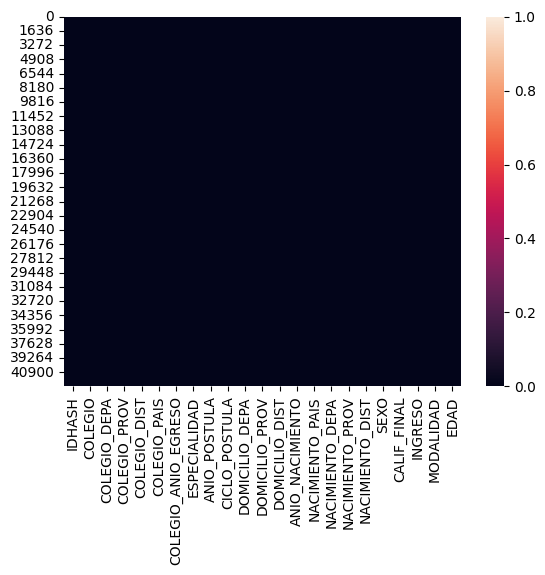

In [ ]:
#verificamos nuevamente el dataset con el mapa de calor
sns.heatmap(entrenamiento.isnull())

In [ ]:
def columnas_con_nulos(entrenamiento):
    # Filtramos las columnas con valores nulos
    columnas_nulas = entrenamiento.isnull().sum()

    # Filtramos solo aquellas columnas que tienen al menos un valor nulo
    columnas_nulas = columnas_nulas[columnas_nulas > 0]

    # Retorna las columnas con nulos y la cantidad de nulos por columna
    return columnas_nulas

# Usamos la función con el DataFrame
columnas_nulas = columnas_con_nulos(entrenamiento)

# Mostrar las columnas con valores nulos
print(columnas_nulas)

CALIF_FINAL    24
dtype: int64


In [ ]:
#codigo para cuando el dataset este completamente lleno
columnas_dummies = [
    'SEXO',
    'MODALIDAD',
    'COLEGIO_PAIS',
    'NACIMIENTO_PAIS',
    'DOMICILIO_DEPA',
    'ESPECIALIDAD'
]

# Aplicar get_dummies a las columnas categóricas
entrenamiento = pd.get_dummies(entrenamiento, columns=columnas_dummies, drop_first=True)

print(entrenamiento.head())


                                              IDHASH  \
0  E4287C2FE19F63C5E6641955147E36684A5A2FF8064676...   
1  2DC37F0B9727B6591EC72D7A942647797A200F45D47C9E...   
2  3B8677B90781D7BB8F2F967C05FA2DBBE153BBB682DF05...   
3  FA366704D9E9F6FB5E5F55C1FB0CEEE973C626A5616F55...   
4  E31CF8F30F3AE60B3D8A14F6E1020E9AD26EE975F0823B...   

                      COLEGIO COLEGIO_DEPA COLEGIO_PROV  \
0       LA DIVINA PROVIDENCIA         LIMA         LIMA   
1           86019 LA LIBERTAD       ÁNCASH       HUARAZ   
2  0113 DANIEL ALOMIAS ROBLES         LIMA         LIMA   
3     SEBASTIAN SALAZAR BONDY         LIMA         LIMA   
4           TRILCE LOS OLIVOS         LIMA         LIMA   

             COLEGIO_DIST  COLEGIO_ANIO_EGRESO  ANIO_POSTULA  CICLO_POSTULA  \
0               SURQUILLO                 2020          2021              1   
1                  HUARAZ                 2017          2021              1   
2  SAN JUAN DE LURIGANCHO                 2016          2021           

In [ ]:
def convertir_ingresos_fila(fila):
    ingreso = fila['INGRESO']
    if pd.isna(ingreso):
        return 0
    return 1 if ingreso == "SI" else 0

entrenamiento['INGRESO'] = entrenamiento.apply(convertir_ingresos_fila, axis=1)


In [ ]:
entrenamiento.head()

,IDHASH,COLEGIO,COLEGIO_DEPA,COLEGIO_PROV,COLEGIO_DIST,COLEGIO_ANIO_EGRESO,ANIO_POSTULA,CICLO_POSTULA,DOMICILIO_PROV,DOMICILIO_DIST,...,ESPECIALIDAD_INGENIERÍA MECÁNICA,ESPECIALIDAD_INGENIERÍA MECÁNICA-ELÉCTRICA,ESPECIALIDAD_INGENIERÍA METALÚRGICA,ESPECIALIDAD_INGENIERÍA NAVAL,ESPECIALIDAD_INGENIERÍA PETROQUÍMICA,ESPECIALIDAD_INGENIERÍA QUÍMICA,ESPECIALIDAD_INGENIERÍA SANITARIA,ESPECIALIDAD_INGENIERÍA TEXTIL,ESPECIALIDAD_MATEMÁTICA,ESPECIALIDAD_QUÍMICA
0,E4287C2FE19F63C5E6641955147E36684A5A2FF8064676...,LA DIVINA PROVIDENCIA,LIMA,LIMA,SURQUILLO,2020,2021,1,LIMA,SAN JUAN DE MIRAFLORES,...,False,False,False,False,False,False,False,False,False,False
1,2DC37F0B9727B6591EC72D7A942647797A200F45D47C9E...,86019 LA LIBERTAD,ÁNCASH,HUARAZ,HUARAZ,2017,2021,1,HUARAZ,HUARAZ,...,False,False,False,False,False,False,False,False,False,False
2,3B8677B90781D7BB8F2F967C05FA2DBBE153BBB682DF05...,0113 DANIEL ALOMIAS ROBLES,LIMA,LIMA,SAN JUAN DE LURIGANCHO,2016,2021,1,LIMA,SAN JUAN DE LURIGANCHO,...,True,False,False,False,False,False,False,False,False,False
3,FA366704D9E9F6FB5E5F55C1FB0CEEE973C626A5616F55...,SEBASTIAN SALAZAR BONDY,LIMA,LIMA,SANTA ANITA,2018,2021,1,LIMA,SANTA ANITA,...,False,False,False,False,False,False,False,False,False,False
4,E31CF8F30F3AE60B3D8A14F6E1020E9AD26EE975F0823B...,TRILCE LOS OLIVOS,LIMA,LIMA,SAN MARTÍN DE PORRES,2020,2021,1,LIMA,INDEPENDENCIA,...,False,False,False,False,False,False,False,False,False,False
